# Kaggle House prices prediction
## Personnale training step 1
### Data exploration

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
blank = pd.read_csv("data/train.csv")
blank.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


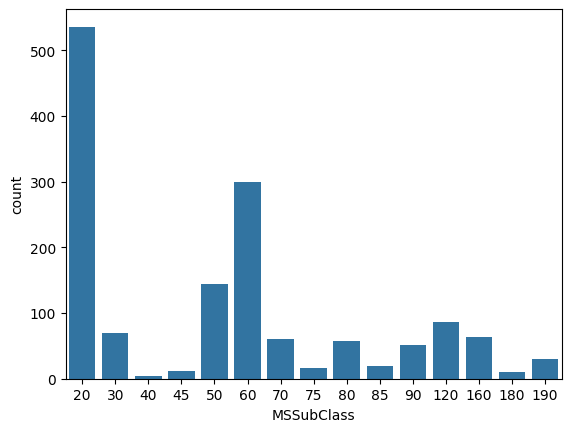

<Axes: xlabel='MSZoning', ylabel='count'>

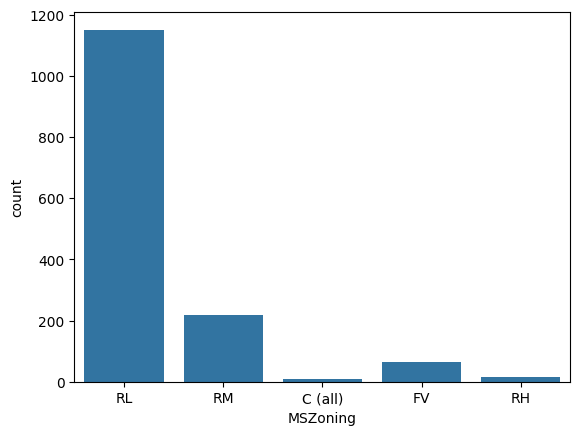

In [56]:
sns.countplot(data = blank, x="MSSubClass")
plt.show()
sns.countplot(data=blank,x="MSZoning")

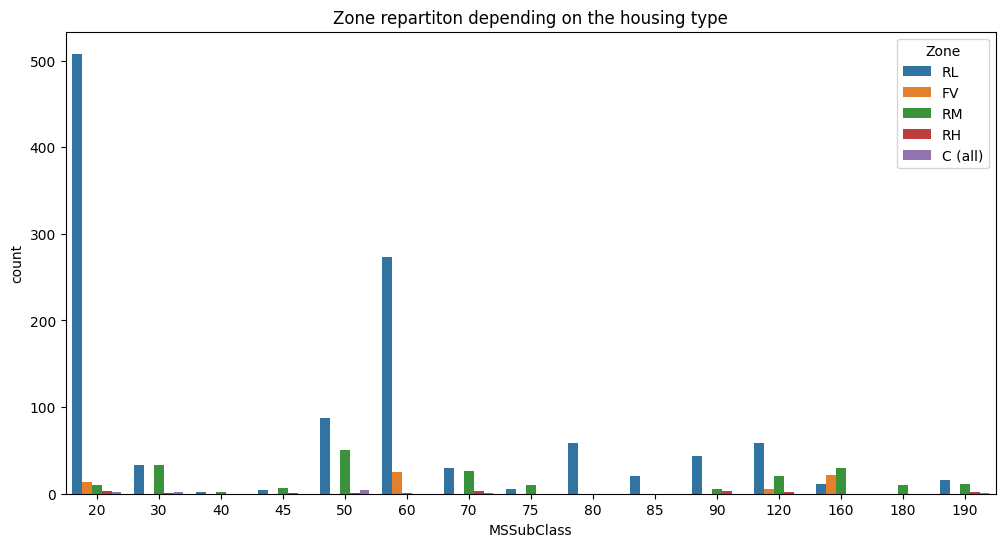

In [57]:
plt.figure(figsize=(12, 6))
sns.countplot(data=blank, x="MSSubClass", hue="MSZoning")
plt.title("Zone repartiton depending on the housing type")
plt.legend(title="Zone", loc='upper right')
plt.show()

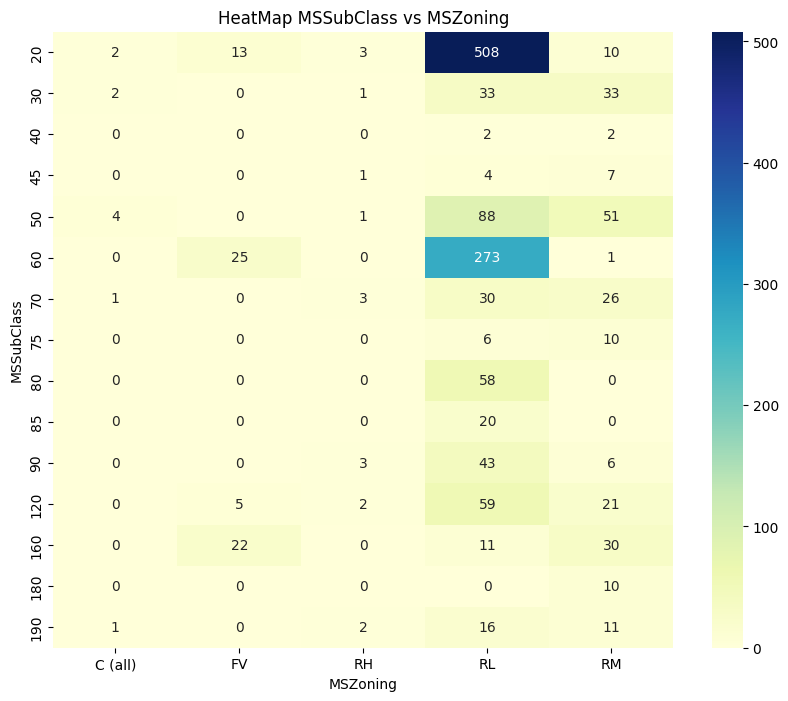

In [58]:
cross_tab = pd.crosstab(blank["MSSubClass"], blank["MSZoning"])
plt.figure(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("HeatMap MSSubClass vs MSZoning")
plt.show()

### Regarding this distribution we can already see that the dataset is pretty unbalanced and that most of the data is either zone RL (Residential Low density) or RM (Residential Medium density) and mostly sub class 20 (1-STORY 1946 & NEWER ALL STYLES) and 60 (2-STORY 1946 & NEWER).
### All that makes sense but it has to be taken in consideration, maybe we should focus on these categories to avoid overfitting 
### Let's keep on going deeper in the dataset analysis to find droppable features.

In [59]:
low_variance_cols = []
for col in blank.select_dtypes(include=['object']).columns:
    top_freq = blank[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95: # 95% threshold
        low_variance_cols.append((col, top_freq))

print("almost constant columns to drop :", low_variance_cols)

almost constant columns to drop : [('Street', np.float64(0.9958904109589041)), ('Utilities', np.float64(0.9993150684931507)), ('Condition2', np.float64(0.9897260273972602)), ('RoofMatl', np.float64(0.9821917808219178)), ('Heating', np.float64(0.9780821917808219)), ('GarageQual', np.float64(0.9506889050036258)), ('GarageCond', np.float64(0.9615663524292966))]


C:\Users\rabie\AppData\Local\Temp\ipykernel_81868\4016496448.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in blank.select_dtypes(include=['object']).columns:


### These columns are way too uniform to be kept, we will then drop them
### When it comes to subclasses and zoning we will perform some regrouping (6 for MSSubClasses and 3 for MSZoning) as the heatmap revealed so many combination are pointless compared to other ones

In [60]:
df_clean = blank.copy()

top_5_subclass = df_clean['MSSubClass'].value_counts().nlargest(5).index
df_clean['MSSubClass'] = df_clean['MSSubClass'].where(df_clean['MSSubClass'].isin(top_5_subclass), 'Other')

top_3_zoning = df_clean['MSZoning'].value_counts().nlargest(2).index
df_clean['MSZoning'] = df_clean['MSZoning'].where(df_clean['MSZoning'].isin(top_3_zoning), 'Other')



print(blank['MSSubClass'].value_counts())
print(df_clean['MSSubClass'].value_counts())
print(blank['MSZoning'].value_counts())
print(df_clean['MSZoning'].value_counts())

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64
MSSubClass
20       536
Other    325
60       299
50       144
120       87
30        69
Name: count, dtype: int64
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
MSZoning
RL       1151
RM        218
Other      91
Name: count, dtype: int64


In [ ]:
to_drop, score = zip(*low_variance_cols)
to_drop = list(to_drop)
df_clean = df_clean.drop(columns=to_drop)

In [ ]:
blank.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyle      1460

In [66]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyle      1460